# Characterization and Changing Nature of Aerosol Extreme Events over the U.S. Southwest

## Raw MERRA-2 files were sliced to U.S. Southwest and converted from UTC to Mountain Time

This code reproduces Figures 3 and 4 from the paper

By: Juliana Mejia Sepulveda
email: julianamejia@arizona.edu


# 1. Libraries

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import os

import scipy
from scipy import stats

import dask
import dask.array as da
import zipfile
import re

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle


import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# 2. Figure 3. TS, WS and Z500 Standardized Anomalies

## 2.1 Reading MERRA data (temperature, wind speed and specific humidity—later used to calculate vpd)

In [2]:
#====Directory====
directory = '/xdisk/sylvia/julianamejia/tmp_merra_slv'

In [3]:
#====Reading files====
ds_hourly_sw = []

# Loop through the files
for archivo in os.listdir(directory):
    if archivo.endswith('.nc4'):
        ruta_archivo = os.path.join(directory, archivo)
        ds_hourly = xr.open_dataset(ruta_archivo, engine="netcdf4")
        ds_hourly_sw.append(ds_hourly)


In [4]:
filtered = [ds for ds in ds_hourly_sw if 'PS' in ds.variables]

#====Concat files by time====
sw_data = xr.concat(filtered, dim='time', coords = 'minimal')
sw_data = sw_data.set_index(time="time")
sw_data = sw_data.sortby("time")
sw_data['time'] = pd.to_datetime(sw_data['time'].values)


In [5]:
#====Calculate hourly wind speed====
sw_data['WS'] = np.sqrt(sw_data['U10M']**2 + sw_data['V10M']**2)
sw_data['WS'].attrs['units'] = 'm/s'
sw_data['WS'].attrs['long_name'] = '10-meter Wind Speed'

### 2.1.1 Resampling to daily max

In [6]:
#====Resample data to daily maximum. U and V components will be used where WS where max====
# 1. Daily max for TS and WS
daily_max_ts = sw_data['TS'].groupby(sw_data['time'].dt.floor('D')).max('time')
daily_max_ws = sw_data['WS'].groupby(sw_data['time'].dt.floor('D')).max('time')

daily_max_ts = daily_max_ts.rename({'floor': 'time'})
daily_max_ws = daily_max_ws.rename({'floor': 'time'})

# 2. Group by day
daily_groups = sw_data.groupby(sw_data['time'].dt.floor('D'))

# 3. Loop over each group to find U and V at max WS
uv_list = []
dates = []

for date, day_data in daily_groups:
    idx = day_data['WS'].argmax(dim='time')
    uv_at_max = day_data.isel(time=idx)[['U10M', 'V10M']]
    uv_list.append(uv_at_max)
    dates.append(np.datetime64(date))

# 4. Combine U and V components into Dataset
for i in range(len(uv_list)):
    uv_list[i] = uv_list[i].reset_coords('time', drop=True) #Drop time first so we can concat by it later

uv_at_ws_max_daily = xr.concat(uv_list, dim='time')
uv_at_ws_max_daily['time'] = ('time', dates)
uv_at_ws_max_daily = uv_at_ws_max_daily.sortby('time')

# 5. Create final dataset with all variables
max_data = xr.Dataset({
    'TS_max': daily_max_ts,
    'WS_max': daily_max_ws,
    'U10M_at_WSmax': uv_at_ws_max_daily['U10M'],
    'V10M_at_WSmax': uv_at_ws_max_daily['V10M']
})


In [7]:
max_data['TS_max'] = max_data['TS_max'] - 273.15
max_data['TS_max'].attrs['units'] = '°C'

### 2.1.2 Computing the events standardized anomalies

In [8]:
# ==== Calculate standardized weekly anomalies for TS and WS ====
lat_min, lat_max = 32, 40
lon_min, lon_max = -120, -108

events = [
    ("2017-08-23", "2017-08-30"),
    ("2020-09-01", "2020-09-07"),
    ("2021-06-08", "2021-06-16"),
    ("2024-07-15", "2024-07-22"),
]

threshold_sigma = 1
EPS = 1e-9

results = []
years_all = np.unique(max_data['time'].dt.year.values)

for start_str, end_str in events:
    start_dt = pd.to_datetime(start_str)
    end_dt   = pd.to_datetime(end_str)
    event_year = start_dt.year

    target_start = start_dt.strftime("%m-%d")
    target_end   = end_dt.strftime("%m-%d")

    # --- Event-week subset ---
    event_week = max_data.sel(time=slice(start_dt, end_dt))
    if event_week.time.size == 0:
        print(f"Skipping event {start_dt.date()} to {end_dt.date()}: no data")
        continue

    # --- Event-week means ---
    ts_event = event_week['TS_max'].mean(dim='time', skipna=True)
    ws_event = event_week['WS_max'].mean(dim='time', skipna=True)
    u_event  = event_week['U10M_at_WSmax'].mean(dim='time', skipna=True)
    v_event  = event_week['V10M_at_WSmax'].mean(dim='time', skipna=True)

    # --- One weekly mean per non-event year ---
    ts_weekly_means = []
    ws_weekly_means = []

    for yr in years_all:
        if yr == event_year:
            continue

        start_y = pd.Timestamp(f"{yr}-{target_start}")
        end_y   = pd.Timestamp(f"{yr}-{target_end}")

        week_y = max_data.sel(time=slice(start_y, end_y))
        if week_y.time.size == 0:
            continue

        ts_weekly_means.append(week_y['TS_max'].mean(dim='time', skipna=True))
        ws_weekly_means.append(week_y['WS_max'].mean(dim='time', skipna=True))

    if len(ts_weekly_means) == 0 or len(ws_weekly_means) == 0:
        print(f"Skipping event {start_dt.date()} to {end_dt.date()}: no climatology weeks")
        continue

    ts_stack = xr.concat(ts_weekly_means, dim='year')
    ws_stack = xr.concat(ws_weekly_means, dim='year')

    # --- Climatological mean and std of weekly means ---
    ts_clim_mean = ts_stack.mean(dim='year', skipna=True)
    ws_clim_mean = ws_stack.mean(dim='year', skipna=True)

    ts_clim_std = ts_stack.std(dim='year', skipna=True, ddof=1)
    ws_clim_std = ws_stack.std(dim='year', skipna=True, ddof=1)

    ts_clim_std = xr.where(ts_clim_std < EPS, np.nan, ts_clim_std)
    ws_clim_std = xr.where(ws_clim_std < EPS, np.nan, ws_clim_std)

    # --- Standardized weekly anomalies ---
    ts_z = (ts_event - ts_clim_mean) / ts_clim_std
    ws_z = (ws_event - ws_clim_mean) / ws_clim_std

    # --- Threshold mask inside standardized anomaly space ---
    mask_sigma = ts_z > threshold_sigma

    # --- Rectangle mask ---
    rect_mask = (
        (ts_z['lat'] >= lat_min) & (ts_z['lat'] <= lat_max)
    ) & (
        (ts_z['lon'] >= lon_min) & (ts_z['lon'] <= lon_max)
    )

    rect_mask_2d = rect_mask.broadcast_like(ts_z)
    valid_rect = rect_mask_2d & np.isfinite(ts_z)

    n_valid = valid_rect.sum().item()

    if n_valid > 0:
        n_sigma = (mask_sigma & valid_rect).sum().item()
        pct_sigma = 100 * n_sigma / n_valid
    else:
        pct_sigma = np.nan

    results.append((
        ts_z.transpose('lat', 'lon'),
        ws_z.transpose('lat', 'lon'),
        u_event.transpose('lat', 'lon'),
        v_event.transpose('lat', 'lon'),
        mask_sigma.transpose('lat', 'lon'),
        pct_sigma
    ))

## 2.2 Reading MERRA data (geopotential height)

In [9]:
#====Directory====
dir_geo = '/xdisk/sylvia/julianamejia/tmp_merra_geo_sw'

In [10]:
#====Reading files====
ds_geopotential_sw = []
file_names = []
errors = []


for archivo in os.listdir(dir_geo):
    if archivo.endswith('.nc4'):
        file_path = os.path.join(dir_geo, archivo)
        try:
            ds_geopotential = xr.open_dataset(file_path, engine="netcdf4")
            ds_geopotential_sw.append(ds_geopotential)
            file_names.append(archivo)
        except FileNotFoundError:
            errors.append(archivo)

In [11]:
#====Concat files by time====
geop_data = xr.concat(ds_geopotential_sw, dim='time', coords='minimal')
geop_data = geop_data.set_index(time='time')
geop_data = geop_data.sortby('time')

### 2.2.1 Resampling to daily max

In [12]:
#====Resample data to daily maximum. U and V components will be used where WS where max====
# 1. Select level closest to 500 hPa
lev_500 = geop_data.sel(lev=500, method='nearest')

# 2. Get daily max of H at 500 hPa
daily_max_H = lev_500['H'].groupby(lev_500['time'].dt.floor('D')).max('time')

# 3. Group full 500 hPa-level data by day
daily_groups = lev_500.groupby(lev_500['time'].dt.floor('D'))

# 4. Loop to find T, U, V at time of max H
uvt_list = []
dates = []

for date, day_data in daily_groups:
    idx = day_data['H'].argmax(dim='time')
    selected = day_data.isel(time=idx)[['T', 'U', 'V']]
    selected = selected.reset_coords('time', drop=True)
    
    # Compute WS = sqrt(U² + V²)
    ws = np.sqrt(selected['U']**2 + selected['V']**2)
    selected['WS'] = ws
    
    uvt_list.append(selected)
    dates.append(np.datetime64(date))

# 5. Concatenate results
uvt_at_Hmax = xr.concat(uvt_list, dim='time')
uvt_at_Hmax['time'] = ('time', dates)
uvt_at_Hmax = uvt_at_Hmax.sortby('time')

#6. Rename H_max dimension to match the other variables
daily_max_H = daily_max_H.rename({'floor': 'time'})

# 7. Final dataset
max_geo500 = xr.Dataset({
    'H_max': daily_max_H,
    'T_at_Hmax': uvt_at_Hmax['T'],
    'U_at_Hmax': uvt_at_Hmax['U'],
    'V_at_Hmax': uvt_at_Hmax['V'],
    'WS_at_Hmax': uvt_at_Hmax['WS']
})

#max_geo500

In [13]:
# === Calculate standardized weekly anomalies for each event ===
events = [
    ("2017-08-23", "2017-08-30"),
    ("2020-09-01", "2020-09-07"),
    ("2021-06-08", "2021-06-16"),
    ("2024-07-15", "2024-07-22"),
]

std_anomaly_results_H500 = []
wind_vectors_H500 = []

EPS = 1e-6
years_all = np.unique(max_geo500['time'].dt.year.values)

for start_str, end_str in events:
    start_dt = pd.to_datetime(start_str)
    end_dt   = pd.to_datetime(end_str)
    event_year = start_dt.year

    target_start = start_dt.strftime("%m-%d")
    target_end   = end_dt.strftime("%m-%d")

    # --- Event-week mean ---
    event_week = max_geo500.sel(time=slice(start_dt, end_dt))
    if event_week.time.size == 0:
        print(f"Skipping event {start_dt.date()} to {end_dt.date()}: no data")
        continue

    h_event_mean = event_week['H_max'].mean(dim='time', skipna=True)

    # actual event-week wind vectors
    u_mean = event_week['U_at_Hmax'].mean(dim='time', skipna=True).transpose('lat', 'lon')
    v_mean = event_week['V_at_Hmax'].mean(dim='time', skipna=True).transpose('lat', 'lon')

    # --- One weekly mean per non-event year ---
    weekly_means = []

    for yr in years_all:
        if yr == event_year:
            continue

        start_y = pd.Timestamp(f"{yr}-{target_start}")
        end_y   = pd.Timestamp(f"{yr}-{target_end}")

        week_y = max_geo500.sel(time=slice(start_y, end_y))

        if week_y.time.size > 0:
            weekly_means.append(week_y['H_max'].mean(dim='time', skipna=True))

    if len(weekly_means) == 0:
        print(f"Skipping event {start_dt.date()} to {end_dt.date()}: no climatology weeks")
        continue

    clim_stack = xr.concat(weekly_means, dim='year')
    clim_years = [yr for yr in years_all if yr != event_year][:len(weekly_means)]
    clim_stack = clim_stack.assign_coords(year=("year", clim_years))

    # --- Climatological mean and std of weekly means ---
    h_clim = clim_stack.mean(dim='year', skipna=True)
    h_std  = clim_stack.std(dim='year', ddof=1, skipna=True)
    h_std  = xr.where(h_std < EPS, np.nan, h_std)

    # --- Standardized weekly anomaly ---
    h_z = ((h_event_mean - h_clim) / h_std).transpose('lat', 'lon')
    std_anomaly_results_H500.append(h_z)

    wind_vectors_H500.append((u_mean, v_mean))

## 2.3. Figure 3

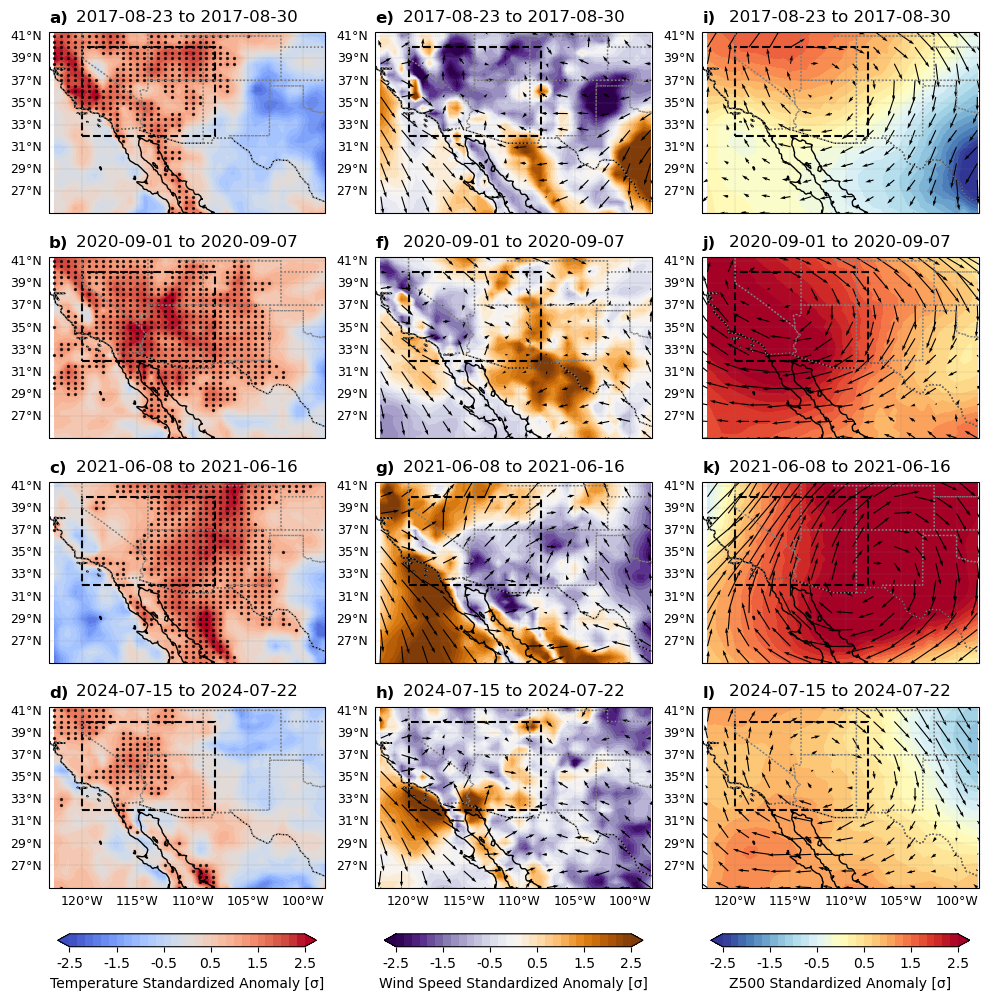

In [14]:
# =========================================================
# Shared settings
# =========================================================
titles = [
    "2017-08-23 to 2017-08-30",
    "2020-09-01 to 2020-09-07",
    "2021-06-08 to 2021-06-16",
    "2024-07-15 to 2024-07-22"
]

ts_labels = ['a', 'b', 'c', 'd']
ws_labels = ['e', 'f', 'g', 'h']
h_labels  = ['i', 'j', 'k', 'l']

extent_ts_ws = [-123, -98, 25, 41]

lat_min, lat_max = 32, 40
lon_min, lon_max = -120, -108

# =========================================================
# Fixed symmetric ranges (adjust if needed)
# =========================================================
vabs_ts = 2.5
vabs_ws = 2.5
vabs_h  = 2.5

ts_norm = TwoSlopeNorm(vcenter=0, vmin=-vabs_ts, vmax=vabs_ts)
ws_norm = TwoSlopeNorm(vcenter=0, vmin=-vabs_ws, vmax=vabs_ws)
h_norm  = TwoSlopeNorm(vcenter=0, vmin=-vabs_h,  vmax=vabs_h)

# =========================================================
# Create figure
# =========================================================
fig, axes = plt.subplots(
    4, 3, figsize=(12, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
fig.subplots_adjust(wspace=0.18, hspace=0.18)

pcm_ts0 = None
pcm_ws0 = None
pcm_h0  = None

for i in range(4):
    # unpack TS / WS results
    ts, ws, u, v, mask_sigma, pct_sigma = results[i]

    # unpack H500 results
    h_z = std_anomaly_results_H500[i]
    u_h, v_h = wind_vectors_H500[i]

    # coordinate grids
    lon2d_ts, lat2d_ts = np.meshgrid(ts['lon'], ts['lat'])
    lon2d_h,  lat2d_h  = np.meshgrid(h_z['lon'], h_z['lat'])

    # -----------------------------------------------------
    # Column 1: Temperature
    # -----------------------------------------------------
    ax_ts = axes[i, 0]
    ax_ts._autoscaleXon = False
    ax_ts._autoscaleYon = False
    ax_ts.set_extent(extent_ts_ws)

    pcm_ts = ax_ts.contourf(
        lon2d_ts, lat2d_ts, ts,
        cmap='coolwarm',
        norm=ts_norm,
        levels=np.linspace(-vabs_ts, vabs_ts, 31),
        transform=ccrs.PlateCarree(),
        extend='both'
    )
    if i == 0:
        pcm_ts0 = pcm_ts

    # dots above threshold
    y_mask, x_mask = np.where(mask_sigma.values & np.isfinite(ts.values))
    if y_mask.size > 0:
        ax_ts.scatter(
            lon2d_ts[y_mask, x_mask],
            lat2d_ts[y_mask, x_mask],
            s=1.8, c='black', alpha=0.8,
            transform=ccrs.PlateCarree()
        )

    ax_ts.add_patch(Rectangle(
        (lon_min, lat_min),
        lon_max - lon_min,
        lat_max - lat_min,
        linewidth=1.5, edgecolor='black', facecolor='none',
        linestyle='--', transform=ccrs.PlateCarree()
    ))

    ax_ts.set_title(titles[i], fontsize=12)
    ax_ts.add_feature(cf.COASTLINE)
    ax_ts.add_feature(cf.BORDERS, linestyle=':')
    ax_ts.add_feature(cf.STATES, linestyle=':', edgecolor='gray')

    gl = ax_ts.gridlines(draw_labels=True, linewidth=0.3,
                         color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    gl.ylocator = mticker.FixedLocator(np.arange(25, 42, 2))
    if i < 3:
        gl.bottom_labels = False

    ax_ts.text(
        0.001, 1.12, f"{ts_labels[i]})",
        transform=ax_ts.transAxes,
        fontsize=12, fontweight='bold', va='top', ha='left'
    )

    # -----------------------------------------------------
    # Column 2: Wind Speed
    # -----------------------------------------------------
    ax_ws = axes[i, 1]
    ax_ws._autoscaleXon = False
    ax_ws._autoscaleYon = False
    ax_ws.set_extent(extent_ts_ws)

    pcm_ws = ax_ws.contourf(
        lon2d_ts, lat2d_ts, ws,
        cmap='PuOr_r',
        norm=ws_norm,
        levels=np.linspace(-vabs_ws, vabs_ws, 31),
        transform=ccrs.PlateCarree(),
        extend='both'
    )
    if i == 0:
        pcm_ws0 = pcm_ws

    step = 3
    ax_ws.quiver(
        lon2d_ts[::step, ::step], lat2d_ts[::step, ::step],
        np.nan_to_num(u.values)[::step, ::step],
        np.nan_to_num(v.values)[::step, ::step],
        color='black', scale=100, width=0.004,
        transform=ccrs.PlateCarree()
    )

    ax_ws.add_patch(Rectangle(
        (lon_min, lat_min),
        lon_max - lon_min,
        lat_max - lat_min,
        linewidth=1.5, edgecolor='black', facecolor='none',
        linestyle='--', transform=ccrs.PlateCarree()
    ))

    ax_ws.set_title(titles[i], fontsize=12)
    ax_ws.add_feature(cf.COASTLINE)
    ax_ws.add_feature(cf.BORDERS, linestyle=':')
    ax_ws.add_feature(cf.STATES, linestyle=':', edgecolor='gray')

    gl = ax_ws.gridlines(draw_labels=True, linewidth=0.3,
                         color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    gl.ylocator = mticker.FixedLocator(np.arange(25, 42, 2))
    if i < 3:
        gl.bottom_labels = False

    ax_ws.text(
        0.001, 1.12, f"{ws_labels[i]})",
        transform=ax_ws.transAxes,
        fontsize=12, fontweight='bold', va='top', ha='left'
    )

    # -----------------------------------------------------
    # Column 3: Z500
    # -----------------------------------------------------
    ax_h = axes[i, 2]
    ax_h._autoscaleXon = False
    ax_h._autoscaleYon = False
    ax_h.set_extent(extent_ts_ws)

    pcm_h = ax_h.contourf(
        lon2d_h, lat2d_h, h_z,
        cmap='RdYlBu_r',
        norm=h_norm,
        levels=np.linspace(-vabs_h, vabs_h, 31),
        transform=ccrs.PlateCarree(),
        extend='both'
    )
    if i == 0:
        pcm_h0 = pcm_h

    u_vals_h = np.nan_to_num(getattr(u_h, "values", u_h))
    v_vals_h = np.nan_to_num(getattr(v_h, "values", v_h))
    ax_h.quiver(
        lon2d_h[::step, ::step], lat2d_h[::step, ::step],
        u_vals_h[::step, ::step], v_vals_h[::step, ::step],
        color='black', scale=100, width=0.004,
        transform=ccrs.PlateCarree()
    )

    ax_h.add_patch(Rectangle(
        (lon_min, lat_min),
        lon_max - lon_min,
        lat_max - lat_min,
        linewidth=1.5, edgecolor='black', facecolor='none',
        linestyle='--', transform=ccrs.PlateCarree()
    ))

    ax_h.set_title(titles[i], fontsize=12)
    ax_h.add_feature(cf.COASTLINE)
    ax_h.add_feature(cf.BORDERS, linestyle=':')
    ax_h.add_feature(cf.STATES, linestyle=':', edgecolor='gray')

    gl = ax_h.gridlines(draw_labels=True, linewidth=0.3,
                        color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    gl.ylocator = mticker.FixedLocator(np.arange(25, 43, 2))
    if i < 3:
        gl.bottom_labels = False

    ax_h.text(
        0.001, 1.12, f"{h_labels[i]})",
        transform=ax_h.transAxes,
        fontsize=12, fontweight='bold', va='top', ha='left'
    )

# =========================================================
# Colorbars
# =========================================================
cbar_ts = fig.colorbar(
    pcm_ts0, ax=axes[:, 0].tolist(),
    orientation='horizontal', fraction=0.014, pad=0.05
)
cbar_ts.set_label('Temperature Standardized Anomaly [σ]')
cbar_ts.ax.tick_params(labelsize=10)
cbar_ts.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

ticks_ts = np.arange(-vabs_ts, vabs_ts + 1.0, 1.0)
cbar_ts.set_ticks(ticks_ts)
cbar_ts.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))


cbar_ws = fig.colorbar(
    pcm_ws0, ax=axes[:, 1].tolist(),
    orientation='horizontal', fraction=0.014, pad=0.05
)
cbar_ws.set_label('Wind Speed Standardized Anomaly [σ]')
cbar_ws.ax.tick_params(labelsize=10)
cbar_ws.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

ticks_ws = np.arange(-vabs_ws, vabs_ws + 1.0, 1.0)
cbar_ws.set_ticks(ticks_ws)
cbar_ws.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

cbar_h = fig.colorbar(
    pcm_h0, ax=axes[:, 2].tolist(),
    orientation='horizontal', fraction=0.014, pad=0.05
)
cbar_h.set_label('Z500 Standardized Anomaly [σ]')
cbar_h.ax.tick_params(labelsize=10)
cbar_h.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

ticks_h = np.arange(-vabs_h, vabs_h + 1.0, 1.0)
cbar_h.set_ticks(ticks_h)
cbar_h.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.savefig('Figure3_Temperature_Wind_Speed__Z500_Standardized_Anomalies.png', dpi=200, bbox_inches='tight')
plt.show()

In [15]:
print(f"\nPercentage of pixels > {threshold_sigma}σ inside southwest boundaries:\n")

for i, (_, _, _, _, _, pct_sigma) in enumerate(results):
    print(f"{titles[i]}: {pct_sigma:.2f}%")


Percentage of pixels > 1σ inside southwest boundaries:

2017-08-23 to 2017-08-30: 64.12%
2020-09-01 to 2020-09-07: 89.41%
2021-06-08 to 2021-06-16: 57.06%
2024-07-15 to 2024-07-22: 32.35%


# 3. Figure 4. SW and VPD Standardized Anomalies

## 3.1 Calculate VPD

In [16]:
# --- Pull variables ---
T_K   = sw_data['TS']        # K
P_Pa  = sw_data['PS']        # Pa
q     = sw_data['QV10M']     # kg/kg (specific humidity)

# --- Unit conversions before the calculations ---
T_C    = T_K - 273.15        # °C
P_kPa  = P_Pa / 1000.0       # kPa

# --- Saturation vapor pressure (kPa): Tetens equation ---
es_kPa = 0.6108 * np.exp((17.27 * T_C) / (T_C + 237.3))

# --- Actual vapor pressure from specific humidity and pressure (kPa) ---
ea_kPa = (q * P_kPa) / (0.622 + 0.378 * q)

# --- VPD (kPa) ---
VPD = es_kPa - ea_kPa
VPD = xr.where(VPD < 0, 0, VPD)

# --- Attaching to the dataset with its metadata ---
VPD.name = 'VPD'
VPD.attrs.update({
    'units': 'kPa',
    'long_name': 'Vapor Pressure Deficit',
    'description': 'VPD = es - ea; es via Tetens (T in °C), ea from specific humidity and surface pressure'
})
sw_data = sw_data.assign(VPD=VPD)

## 3.2 Reading volumetric soil moisture from ERA5

In [17]:
#==== Reading files====
data_dir = '/xdisk/sylvia/julianamejia/era5land_soilmoisture/'


layer1_files = sorted([
    os.path.join(data_dir, f)
    for f in os.listdir(data_dir)
    if f.startswith('volumetric_soil_water_layer_1_0_daily-max_') and f.endswith('.nc')
])


ds_list = []
for file in layer1_files:
    ds = xr.open_dataset(file)
    ds_list.append(ds)

In [18]:
#====Concatenate====
soil_water = xr.concat(ds_list, dim="valid_time")

## 3.3 Figure 4

### 3.3.1 Compute weekly standardized anomalies

In [19]:
# ---------- 1) Prep time axis ----------
ds = sw_data
t = pd.to_datetime(ds['time'].values)
ds = ds.assign_coords(time=t).sortby('time')
_, keep = np.unique(ds['time'].values, return_index=True)
if len(keep) != ds.sizes['time']:
    ds = ds.isel(time=np.sort(keep))

# ---------- 2) Daily aggregation (Using daily max) ----------
VPD_daily = ds['VPD'].groupby(ds['time'].dt.floor('D')).max().rename({'floor': 'time'})

# ---------- 3) Event periods ----------
titles = [
    "2017-08-23 to 2017-08-30",
    "2020-09-01 to 2020-09-07",
    "2021-06-08 to 2021-06-16",
    "2024-07-15 to 2024-07-22"
]

def parse_range(t):
    start, end = [s.strip() for s in t.split("to")]
    return pd.to_datetime(start), pd.to_datetime(end)

periods = [parse_range(t) for t in titles]

# ---------- 4) Weekly standardized anomalies ----------
# Method:
# standardized anomaly = (event-week mean - climatological mean of weekly means
# for the same calendar window across all other years) / climatological std of weekly means

vpd_std_weekly_means = []
EPS = 1e-9

years_all = np.unique(VPD_daily['time'].dt.year.values)

for start_dt, end_dt in periods:
    event_year = start_dt.year
    target_start = start_dt.strftime("%m-%d")
    target_end   = end_dt.strftime("%m-%d")

    # --- Event-week mean ---
    event_week = VPD_daily.sel(time=slice(start_dt, end_dt))
    if event_week.time.size == 0:
        print(f"Skipping event {start_dt.date()} to {end_dt.date()}: no data")
        continue

    vpd_event_mean = event_week.mean(dim='time', skipna=True)

    # --- One weekly mean per non-event year ---
    weekly_means = []

    for yr in years_all:
        if yr == event_year:
            continue

        start_y = pd.Timestamp(f"{yr}-{target_start}")
        end_y   = pd.Timestamp(f"{yr}-{target_end}")

        week_y = VPD_daily.sel(time=slice(start_y, end_y))

        # Keep only years with data in that window
        if week_y.time.size > 0:
            weekly_means.append(week_y.mean(dim='time', skipna=True))

    if len(weekly_means) == 0:
        print(f"Skipping event {start_dt.date()} to {end_dt.date()}: no climatology weeks")
        continue

    clim_stack = xr.concat(weekly_means, dim='year')

    # Use real year values as coordinate
    clim_years = [yr for yr in years_all if yr != event_year][:len(weekly_means)]
    clim_stack = clim_stack.assign_coords(year=("year", clim_years))

    # --- Climatological mean and std of weekly means ---
    clim_mean = clim_stack.mean(dim='year', skipna=True)
    clim_std  = clim_stack.std(dim='year', skipna=True, ddof=1)
    clim_std  = xr.where(clim_std < EPS, np.nan, clim_std)

    # --- Standardized weekly anomaly ---
    vpd_z = (vpd_event_mean - clim_mean) / clim_std
    vpd_z.name = 'VPD_standardized_anomaly'
    vpd_z.attrs.update({
        'units': 'σ',
        'long_name': 'Weekly standardized VPD anomaly'
    })

    vpd_std_weekly_means.append(vpd_z)

In [20]:
# ==== Calculate standardized weekly anomalies for soil moisture ====
events = [
    ("2017-08-23", "2017-08-30"),
    ("2020-09-01", "2020-09-07"),
    ("2021-06-08", "2021-06-16"),
    ("2024-07-15", "2024-07-22")
]

soil_moist_anomalies = []
EPS = 1e-9

years_all = np.unique(soil_water['valid_time'].dt.year.values)

for start_str, end_str in events:
    start_dt = pd.to_datetime(start_str)
    end_dt = pd.to_datetime(end_str)
    event_year = start_dt.year

    target_start = start_dt.strftime("%m-%d")
    target_end   = end_dt.strftime("%m-%d")

    # --- Event-week mean ---
    event_week = soil_water.sel(valid_time=slice(start_dt, end_dt))
    if event_week.valid_time.size == 0:
        print(f"Skipping event {start_dt.date()} to {end_dt.date()}: no data")
        continue

    sm_event_mean = event_week.mean(dim='valid_time', skipna=True)

    # --- One weekly mean per non-event year ---
    weekly_means = []

    for yr in years_all:
        if yr == event_year:
            continue

        start_y = pd.Timestamp(f"{yr}-{target_start}")
        end_y   = pd.Timestamp(f"{yr}-{target_end}")

        week_y = soil_water.sel(valid_time=slice(start_y, end_y))

        if week_y.valid_time.size > 0:
            weekly_means.append(week_y.mean(dim='valid_time', skipna=True))

    if len(weekly_means) == 0:
        print(f"Skipping event {start_dt.date()} to {end_dt.date()}: no climatology weeks")
        continue

    clim_stack = xr.concat(weekly_means, dim='year')
    clim_years = [yr for yr in years_all if yr != event_year][:len(weekly_means)]
    clim_stack = clim_stack.assign_coords(year=("year", clim_years))

    # --- Climatological mean and std of weekly means ---
    sm_clim = clim_stack.mean(dim='year', skipna=True)
    sd_clim = clim_stack.std(dim='year', skipna=True, ddof=1)
    sd_clim = xr.where(sd_clim < EPS, np.nan, sd_clim)

    # --- Standardized weekly anomaly ---
    sm_mean_anom = (sm_event_mean - sm_clim) / sd_clim

    soil_moist_anomalies.append(sm_mean_anom)

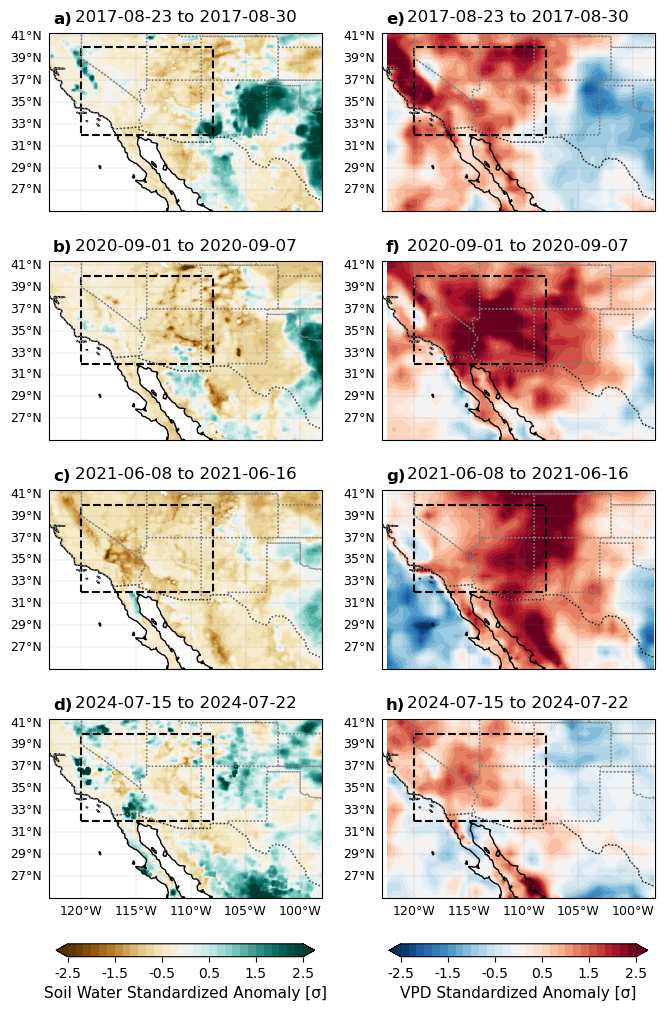

In [21]:
# =========================================================
# Shared settings
# =========================================================
extent = [-123, -98, 25, 41]

titles = [
    "2017-08-23 to 2017-08-30",
    "2020-09-01 to 2020-09-07",
    "2021-06-08 to 2021-06-16",
    "2024-07-15 to 2024-07-22"
]

sm_labels  = ['a', 'b', 'c', 'd']
vpd_labels = ['e', 'f', 'g', 'h']

lat_min, lat_max = 32, 40
lon_min, lon_max = -120, -108

# =========================================================
# Fixed symmetric range for both variables
# =========================================================
vabs_sm = 2.5
vabs_vpd = 2.5

sm_norm = TwoSlopeNorm(vcenter=0, vmin=-vabs_sm, vmax=vabs_sm)
vpd_norm = TwoSlopeNorm(vcenter=0, vmin=-vabs_vpd, vmax=vabs_vpd)

# =========================================================
# Create figure: 4 rows x 2 columns
# =========================================================
fig, axes = plt.subplots(
    4, 2, figsize=(8, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
fig.subplots_adjust(wspace=0.16, hspace=0.28)

pcm_sm = None
pcm_vpd = None

for i in range(4):
    # -----------------------------------------------------
    # LEFT: Soil Moisture
    # -----------------------------------------------------
    ax_sm = axes[i, 0]
    sm_anom = soil_moist_anomalies[i]
    sm_var = sm_anom['swvl1']

    lon_name_sm = 'longitude' if 'longitude' in sm_var.coords else 'lon'
    lat_name_sm = 'latitude' if 'latitude' in sm_var.coords else 'lat'
    lon2d_sm, lat2d_sm = np.meshgrid(sm_var[lon_name_sm], sm_var[lat_name_sm])

    ax_sm._autoscaleXon = False
    ax_sm._autoscaleYon = False
    ax_sm.set_extent(extent)

    pcm_sm = ax_sm.contourf(
        lon2d_sm, lat2d_sm, sm_var,
        cmap='BrBG',
        norm=sm_norm,
        levels=np.linspace(-vabs_sm, vabs_sm, 31),
        transform=ccrs.PlateCarree(),
        extend='both'
    )

    ax_sm.add_patch(Rectangle(
        (lon_min, lat_min),
        lon_max - lon_min,
        lat_max - lat_min,
        linewidth=1.5,
        edgecolor='black',
        facecolor='none',
        linestyle='--',
        transform=ccrs.PlateCarree()
    ))

    ax_sm.set_title(titles[i], fontsize=12)
    ax_sm.add_feature(cf.COASTLINE)
    ax_sm.add_feature(cf.BORDERS, linestyle=':')
    ax_sm.add_feature(cf.STATES, linestyle=':', edgecolor='gray')

    gl = ax_sm.gridlines(draw_labels=True, linewidth=0.3,
                         color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    gl.ylocator = mticker.FixedLocator(np.round(np.arange(25, 47, 2), 1))
    if i < 3:
        gl.bottom_labels = False

    ax_sm.text(
        0.015, 1.12, f"{sm_labels[i]})",
        transform=ax_sm.transAxes,
        fontsize=12, fontweight='bold',
        va='top', ha='left'
    )

    # -----------------------------------------------------
    # RIGHT: VPD
    # -----------------------------------------------------
    ax_vpd = axes[i, 1]
    v = vpd_std_weekly_means[i]

    if 'longitude' in v.coords and 'lon' not in v.coords:
        v = v.rename({'longitude': 'lon'})
    if 'latitude' in v.coords and 'lat' not in v.coords:
        v = v.rename({'latitude': 'lat'})
    v = v.squeeze(drop=True)

    lon2d_vpd, lat2d_vpd = np.meshgrid(v['lon'], v['lat'])

    ax_vpd._autoscaleXon = False
    ax_vpd._autoscaleYon = False
    ax_vpd.set_extent(extent)

    pcm_vpd = ax_vpd.contourf(
        lon2d_vpd, lat2d_vpd, v,
        cmap='RdBu_r',
        norm=vpd_norm,
        levels=np.linspace(-vabs_vpd, vabs_vpd, 31),
        transform=ccrs.PlateCarree(),
        extend='both'
    )

    ax_vpd.add_patch(Rectangle(
        (lon_min, lat_min),
        lon_max - lon_min,
        lat_max - lat_min,
        linewidth=1.5,
        edgecolor='black',
        facecolor='none',
        linestyle='--',
        transform=ccrs.PlateCarree()
    ))

    ax_vpd.set_title(titles[i], fontsize=12)
    ax_vpd.add_feature(cf.COASTLINE)
    ax_vpd.add_feature(cf.BORDERS, linestyle=':')
    ax_vpd.add_feature(cf.STATES, linestyle=':', edgecolor='gray')

    gl = ax_vpd.gridlines(draw_labels=True, linewidth=0.3,
                          color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    gl.ylocator = mticker.FixedLocator(np.round(np.arange(25, 47, 2), 1))
    if i < 3:
        gl.bottom_labels = False

    ax_vpd.text(
        0.015, 1.12, f"{vpd_labels[i]})",
        transform=ax_vpd.transAxes,
        fontsize=12, fontweight='bold',
        va='top', ha='left'
    )

# =========================================================
# Colorbars
# =========================================================
cbar_sm = fig.colorbar(
    pcm_sm, ax=axes[:, 0].tolist(),
    orientation='horizontal',
    fraction=0.014, pad=0.05
)
ticks_sm = np.arange(-vabs_sm, vabs_sm + 1.0, 1.0)
cbar_sm.set_ticks(ticks_sm)

cbar_sm.set_label('Soil Water Standardized Anomaly [σ]', fontsize=11)
cbar_sm.ax.tick_params(labelsize=10)
cbar_sm.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))


cbar_vpd = fig.colorbar(
    pcm_vpd, ax=axes[:, 1].tolist(),
    orientation='horizontal',
    fraction=0.014, pad=0.05
)

ticks_vpd = np.arange(-vabs_vpd, vabs_vpd + 1.0, 1.0)
cbar_vpd.set_ticks(ticks_vpd)

cbar_vpd.set_label('VPD Standardized Anomaly [σ]', fontsize=11)
cbar_vpd.ax.tick_params(labelsize=10)
cbar_vpd.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.savefig('Figure4_Soil_Water_VPD_Standardized_Anomalies.png', dpi=200, bbox_inches='tight')
plt.show()